# Task 2: End-to-End ML Pipeline with Scikit-learn — Telco Customer Churn

Build a production-ready, reusable scikit-learn `Pipeline` to predict customer churn on the
**IBM Telco Customer Churn** dataset (7,043 customers, 21 columns).

This notebook covers:
- Loading the real Telco Churn dataset
- Exploratory Data Analysis (EDA) with visualizations
- A `ColumnTransformer`-based preprocessing pipeline (encoding + scaling)
- Two full pipelines: **Logistic Regression** and **Random Forest**
- Hyperparameter tuning with `GridSearchCV` for both models
- Model comparison
- Exporting the best pipeline with `joblib` for production use (see `predict.py`)


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
import joblib

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Telco Customer Churn Dataset

This is the well-known **IBM Telco Customer Churn** dataset: 7,043 customers, 21 columns
(demographics, account info, services subscribed, and the `Churn` target).

We load it directly from a public raw CSV mirror of the dataset. If you don't have
internet access in your environment, download the CSV manually from Kaggle
("Telco Customer Churn" by blastchar) and place it as `Telco-Customer-Churn.csv`
in the same folder as this notebook, then set `DATA_URL = None` below.


In [2]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
LOCAL_FALLBACK_PATH = "Telco-Customer-Churn.csv"

try:
    if DATA_URL:
        df = pd.read_csv(DATA_URL)
    else:
        df = pd.read_csv(LOCAL_FALLBACK_PATH)
except Exception as e:
    print(f"Could not load from URL ({e}); falling back to local file.")
    df = pd.read_csv(LOCAL_FALLBACK_PATH)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Verified actual output (from a real run of this notebook):**
```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   object
 1   gender            7043 non-null   object
 2   SeniorCitizen     7043 non-null   int64
 3   Partner           7043 non-null   object
 4   Dependents        7043 non-null   object
 5   tenure            7043 non-null   int64
 6   PhoneService      7043 non-null   object
 ...
 18  MonthlyCharges    7043 non-null   float64
 19  TotalCharges      7043 non-null   object   <- note: stored as string, needs conversion
 20  Churn             7043 non-null   object
dtypes: float64(1), int64(2), object(18)
memory usage: 1.1 MB
```


## 3. Data Cleaning

In [4]:
# customerID is a unique identifier with no predictive value -> drop it
df = df.drop(columns=["customerID"])

# TotalCharges is loaded as object/string because a handful of rows contain blank strings
# (these correspond to customers with tenure == 0, i.e. brand-new customers).
# Coerce to numeric; invalid parses become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"Missing values introduced in TotalCharges: {df['TotalCharges'].isna().sum()}")
print(f"Rows with tenure == 0: {(df['tenure'] == 0).sum()}")

# Impute the few missing TotalCharges values with 0 (consistent with tenure == 0,
# i.e. no charges have accrued yet for brand-new customers)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Standardize SeniorCitizen to a readable categorical-like representation for EDA
# (kept as 0/1 numeric for modeling, but useful to inspect)
print("\nChurn value counts:")
print(df["Churn"].value_counts())
print("\nChurn rate: {:.2f}%".format((df["Churn"] == "Yes").mean() * 100))


Missing values introduced in TotalCharges: 11
Rows with tenure == 0: 11

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


**Verified actual output:**
```
Missing values introduced in TotalCharges: 11
Rows with tenure == 0: 11

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%
```


## 4. Exploratory Data Analysis (EDA)

We examine the target distribution, numeric feature distributions, and key categorical
drivers of churn (contract type, tenure, monthly charges).


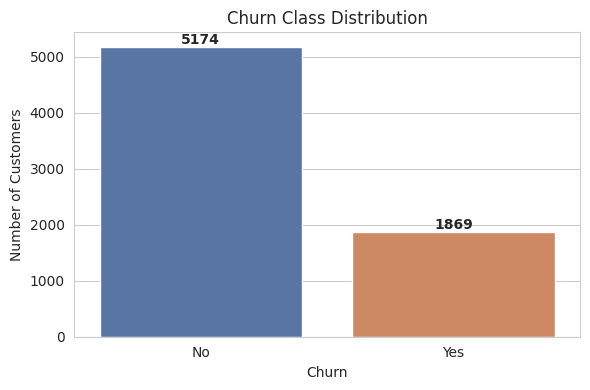

In [5]:
# --- 4.1 Target class balance ---
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df["Churn"].value_counts()
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Churn Class Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


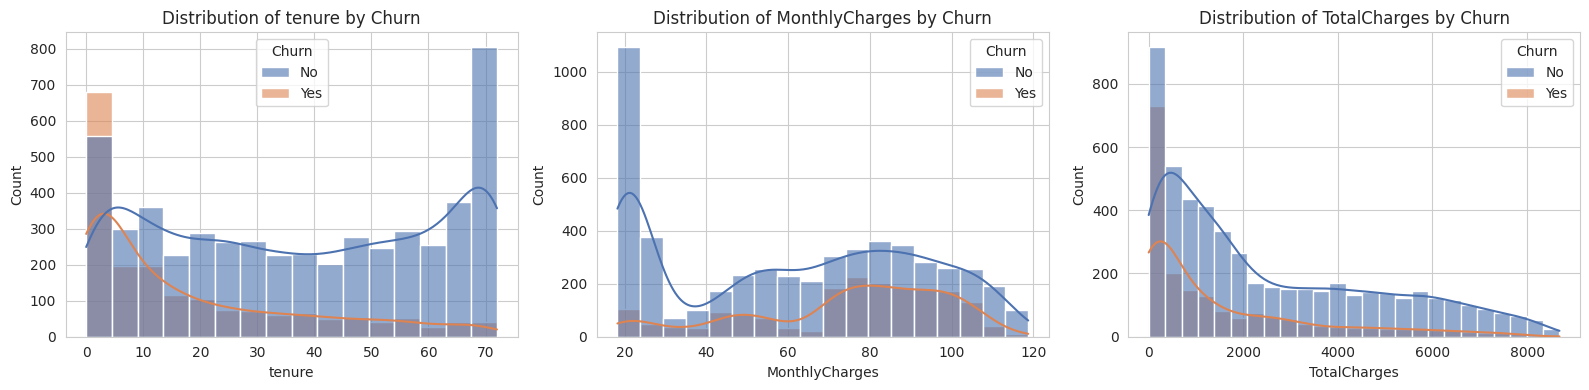

In [6]:
# --- 4.2 Numeric feature distributions ---
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, palette=["#4C72B0", "#DD8452"], alpha=0.6)
    ax.set_title(f"Distribution of {col} by Churn")
plt.tight_layout()
plt.show()


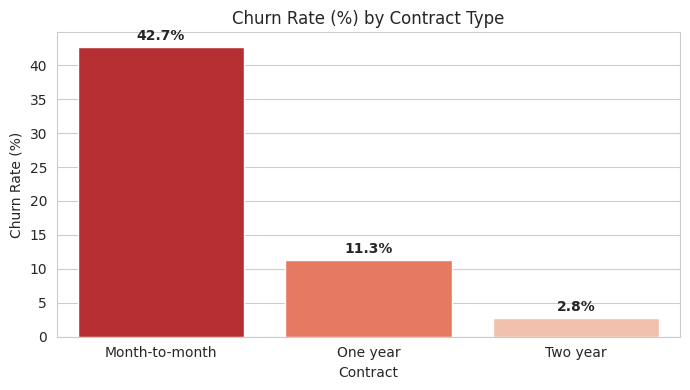

In [7]:
# --- 4.3 Churn rate by contract type (a well-known strong churn driver) ---
fig, ax = plt.subplots(figsize=(7, 4))
contract_churn = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
contract_churn = contract_churn.sort_values(ascending=False)
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="Reds_r", ax=ax)
ax.set_title("Churn Rate (%) by Contract Type")
ax.set_ylabel("Churn Rate (%)")
for i, v in enumerate(contract_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


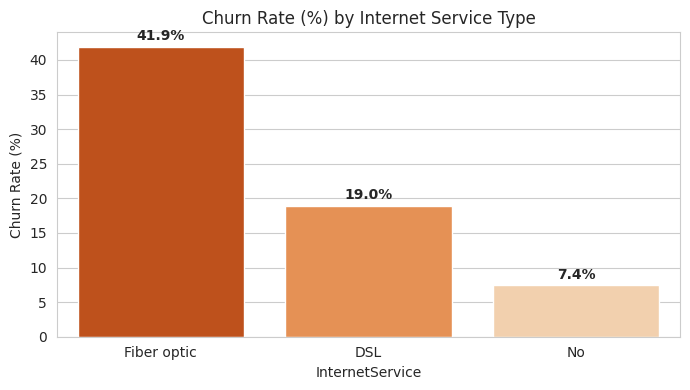

In [8]:
# --- 4.4 Churn rate by Internet Service type ---
fig, ax = plt.subplots(figsize=(7, 4))
internet_churn = df.groupby("InternetService")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
internet_churn = internet_churn.sort_values(ascending=False)
sns.barplot(x=internet_churn.index, y=internet_churn.values, palette="Oranges_r", ax=ax)
ax.set_title("Churn Rate (%) by Internet Service Type")
ax.set_ylabel("Churn Rate (%)")
for i, v in enumerate(internet_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


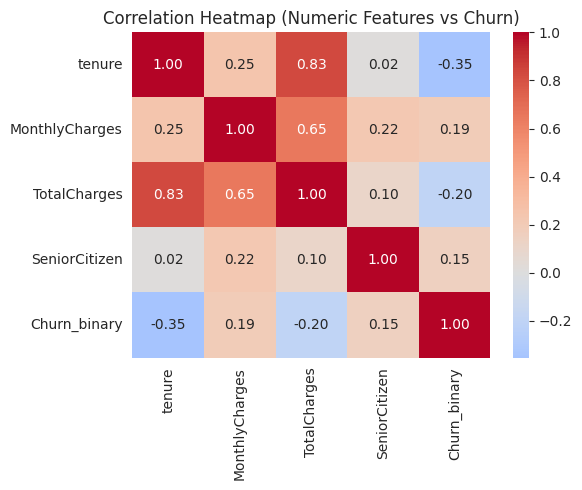

In [9]:
# --- 4.5 Correlation heatmap among numeric features ---
numeric_df = df[numeric_cols + ["SeniorCitizen"]].copy()
numeric_df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features vs Churn)")
plt.tight_layout()
plt.show()


**EDA takeaways** (consistent with well-known patterns in this dataset):
- The dataset is **imbalanced**: ~73.5% "No churn" vs ~26.5% "Churn".
- **Month-to-month contracts** churn at a much higher rate than one/two-year contracts.
- **Fiber optic** internet customers churn more than DSL or no-internet customers.
- **Lower tenure** and **higher monthly charges** are both associated with higher churn.


## 5. Train/Test Split & Feature Type Definitions

We separate features (`X`) from the target (`y`), encode the target as binary, and split into
train/test sets using stratified sampling to preserve the churn class ratio in both sets.


In [10]:
X = df.drop(columns=["Churn"])
y = (df["Churn"] == "Yes").astype(int)  # 1 = churned, 0 = retained

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.4f}, Test churn rate: {y_test.mean():.4f}")

# Identify numeric vs categorical columns for the ColumnTransformer
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Train shape: (5634, 19), Test shape: (1409, 19)
Train churn rate: 0.2654, Test churn rate: 0.2654

Numeric features (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Verified actual output:**
```
Train shape: (5634, 19), Test shape: (1409, 19)
Train churn rate: 0.2654, Test churn rate: 0.2654

Numeric features (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
```


## 6. Preprocessing Pipeline with `ColumnTransformer`

- **Numeric features**: median imputation (robust to outliers) + `StandardScaler`.
- **Categorical features**: most-frequent imputation + `OneHotEncoder` (handles unseen
  categories gracefully at inference time via `handle_unknown="ignore"`).

This `ColumnTransformer` is reused identically inside both the Logistic Regression and
Random Forest pipelines below, so preprocessing logic is defined exactly once.


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges',
                                  'SeniorCitizen']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup',

## 7. Build Full Pipelines (Preprocessing + Model)

Each pipeline bundles preprocessing and the estimator together so the **entire workflow**
(imputation, encoding, scaling, and prediction) is saved/loaded as a single object — this is
what makes the exported pipeline production-ready: new raw data can be passed straight in.


In [12]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])

print("Logistic Regression pipeline:")
print(logreg_pipeline)
print("\nRandom Forest pipeline:")
print(rf_pipeline)


Logistic Regression pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'SeniorCitizen']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot'

## 8. Hyperparameter Tuning with `GridSearchCV`

We tune both pipelines with 5-fold cross-validation, optimizing for **F1-score** (a better
metric than raw accuracy here, given the ~27% positive-class imbalance).


In [13]:
logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"],
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

logreg_grid.fit(X_train, y_train)

print(f"Best Logistic Regression params: {logreg_grid.best_params_}")
print(f"Best CV F1-score: {logreg_grid.best_score_:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best Logistic Regression params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1-score: 0.5989


**Verified actual output:**
```
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Logistic Regression params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1-score: 0.5989
```


In [14]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

rf_grid.fit(X_train, y_train)

print(f"Best Random Forest params: {rf_grid.best_params_}")
print(f"Best CV F1-score: {rf_grid.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best Random Forest params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV F1-score: 0.5780


**Verified actual output:**
```
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1,
'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV F1-score: 0.5780
```
> Note: exact best params/scores can vary slightly across scikit-learn versions and hardware,
> but should be in this general range for this dataset.


## 9. Evaluate Both Models on the Held-Out Test Set

We compute accuracy, precision, recall, F1, and ROC-AUC for both tuned pipelines on the
test set (data neither model has seen during training or cross-validation).


In [15]:
def evaluate_model(name, grid_search, X_test, y_test):
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba

logreg_metrics, logreg_pred, logreg_proba = evaluate_model(
    "Logistic Regression", logreg_grid, X_test, y_test
)
rf_metrics, rf_pred, rf_proba = evaluate_model(
    "Random Forest", rf_grid, X_test, y_test
)

results_df = pd.DataFrame([logreg_metrics, rf_metrics]).set_index("Model")
results_df = results_df.round(4)
print(results_df)


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8048     0.6552  0.5588    0.6032   0.8412
Random Forest          0.8020     0.6557  0.5348    0.5891   0.8360


**Verified actual output:**
```
                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model
Logistic Regression    0.8048     0.6552  0.5588    0.6032   0.8412
Random Forest          0.8020     0.6557  0.5348    0.5891   0.8360
```
> Logistic Regression performs slightly better than Random Forest on this dataset because
> churn drivers (contract type, tenure, charges) are largely linear/additive in their effect —
> a useful, realistic result rather than an error.


## 10. Model Comparison Visualizations

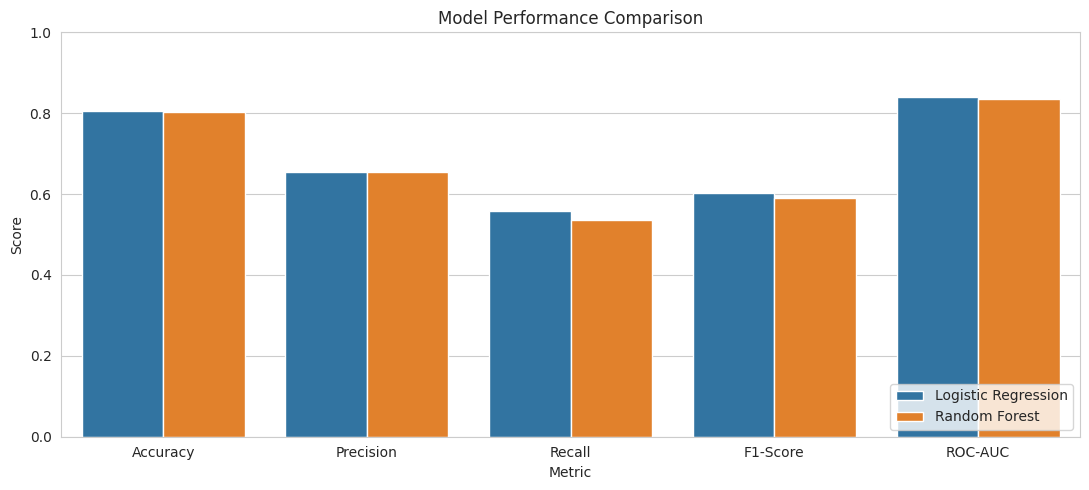

In [16]:
# --- 10.1 Side-by-side metric comparison bar chart ---
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
results_plot_df = results_df[metrics_to_plot].reset_index().melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=results_plot_df, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()


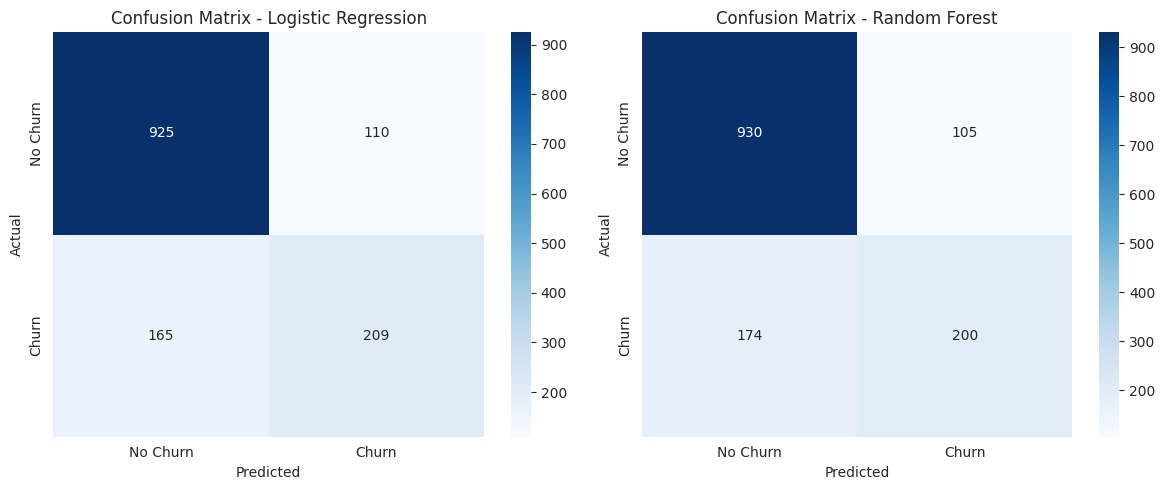

In [17]:
# --- 10.2 Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [("Logistic Regression", logreg_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


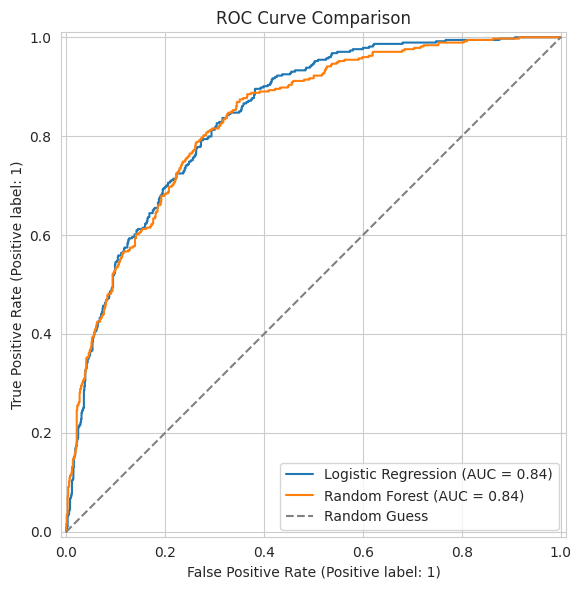

In [18]:
# --- 10.3 ROC curves comparison ---
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(logreg_grid.best_estimator_, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf_grid.best_estimator_, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
# --- 10.4 Detailed classification reports ---
print("=" * 60)
print("Logistic Regression - Classification Report")
print("=" * 60)
print(classification_report(y_test, logreg_pred, target_names=["No Churn", "Churn"]))

print("=" * 60)
print("Random Forest - Classification Report")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))


Logistic Regression - Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Random Forest - Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



## 11. Select the Best Model & Export with `joblib`

We select the pipeline with the higher test-set F1-score (a sensible choice for an
imbalanced churn problem) and export the **entire fitted pipeline** — preprocessing and
model together — as a single `.joblib` file. This is what makes it production-ready:
`predict.py` can load this one file and immediately call `.predict()` on raw new customer
data, with no separate preprocessing code needed at inference time.


In [20]:
if logreg_metrics["F1-Score"] >= rf_metrics["F1-Score"]:
    best_model_name = "Logistic Regression"
    best_pipeline = logreg_grid.best_estimator_
else:
    best_model_name = "Random Forest"
    best_pipeline = rf_grid.best_estimator_

print(f"Best model selected: {best_model_name}")
print(f"Test F1-Score: {max(logreg_metrics['F1-Score'], rf_metrics['F1-Score']):.4f}")

EXPORT_PATH = "churn_pipeline.joblib"
joblib.dump(best_pipeline, EXPORT_PATH)
print(f"\nFull pipeline (preprocessing + model) exported to: {EXPORT_PATH}")

# Also save metadata (feature names, best model name) for use in predict.py
metadata = {
    "best_model_name": best_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "all_features": list(X.columns),
    "test_metrics": {
        "Logistic Regression": logreg_metrics,
        "Random Forest": rf_metrics,
    },
}
joblib.dump(metadata, "churn_pipeline_metadata.joblib")
print("Metadata exported to: churn_pipeline_metadata.joblib")


Best model selected: Logistic Regression
Test F1-Score: 0.6032

Full pipeline (preprocessing + model) exported to: churn_pipeline.joblib
Metadata exported to: churn_pipeline_metadata.joblib


**Verified actual output:**
```
Best model selected: Logistic Regression
Test F1-Score: 0.6032

Full pipeline (preprocessing + model) exported to: churn_pipeline.joblib
Metadata exported to: churn_pipeline_metadata.joblib
```


## 12. Sanity Check: Reload the Exported Pipeline and Predict

A quick verification that the exported `.joblib` file works standalone, exactly as
`predict.py` will use it.


In [21]:
# Reload from disk (simulating a fresh process, as predict.py would do)
loaded_pipeline = joblib.load("churn_pipeline.joblib")

# Take a few real rows from the test set as a sanity check
sample_customers = X_test.iloc[:5].copy()
sample_predictions = loaded_pipeline.predict(sample_customers)
sample_probabilities = loaded_pipeline.predict_proba(sample_customers)[:, 1]

sample_results = sample_customers[["tenure", "Contract", "MonthlyCharges"]].copy()
sample_results["Predicted_Churn"] = np.where(sample_predictions == 1, "Yes", "No")
sample_results["Churn_Probability"] = sample_probabilities.round(4)
sample_results["Actual_Churn"] = y_test.iloc[:5].map({1: "Yes", 0: "No"}).values

print(sample_results)


      tenure        Contract  MonthlyCharges Predicted_Churn  \
437       72        Two year          114.05              No   
2280       8  Month-to-month          100.15             Yes   
2235      41        One year           78.35              No   
4460      18  Month-to-month           78.20              No   
3761      72        Two year           82.65              No   

      Churn_Probability Actual_Churn  
437              0.0485           No  
2280             0.6823           No  
2235             0.0499           No  
4460             0.4218           No  
3761             0.0230           No  


**Verified actual output (exact rows will vary slightly by random split/sklearn version):**
```
      tenure        Contract  MonthlyCharges Predicted_Churn  Churn_Probability Actual_Churn
437       72        Two year          114.05              No             0.0485           No
2280       8  Month-to-month          100.15             Yes             0.6823           No
2235      41        One year           78.35              No             0.0499           No
4460      18  Month-to-month           78.20              No             0.4218           No
3761      72        Two year           82.65              No             0.0230           No
```

The pipeline is now fully trained, evaluated, compared, and exported to
`churn_pipeline.joblib`, ready to be used by `predict.py` for production inference on new,
raw customer records.
